<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Predict_Insurance_Charges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2 : Predict Insurance Charges**

**Objective**

Build a machine learning regression model to predict medical insurance charges based on customer attributes such as:

Age

Gender

BMI

Number of children

Smoking status

Region

This project simulates a real-world insurance analytics system used by insurance companies to estimate medical costs for new customers.

# **1. Problem Statement**

Insurance companies need accurate cost prediction systems to:

Estimate customer medical expenses

Determine insurance premiums

Reduce financial risk

Improve pricing strategies

**The target variable is:**

                    Insurance Charges

This is a supervised machine learning regression problem.

# **2. Machine Learning Workflow**

Data Collection

      ↓
Data Cleaning

      ↓
Exploratory Data Analysis

      ↓
Feature Encoding

      ↓
Train/Test Split

      ↓
Model Training

      ↓
Evaluation

      ↓
Prediction System

# **3. Dataset**

Recommended Dataset:

**Medical Cost Personal Dataset (Kaggle)**

# **4. Install Required Libraries**

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# **5. Complete Project Code**

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# **6. Load Dataset**

In [3]:
df = pd.read_csv("insurance.csv")

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# **7. Data Exploration**

**Dataset Information**

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

**Check Missing Values**

In [5]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# **Correlation Heatmap**

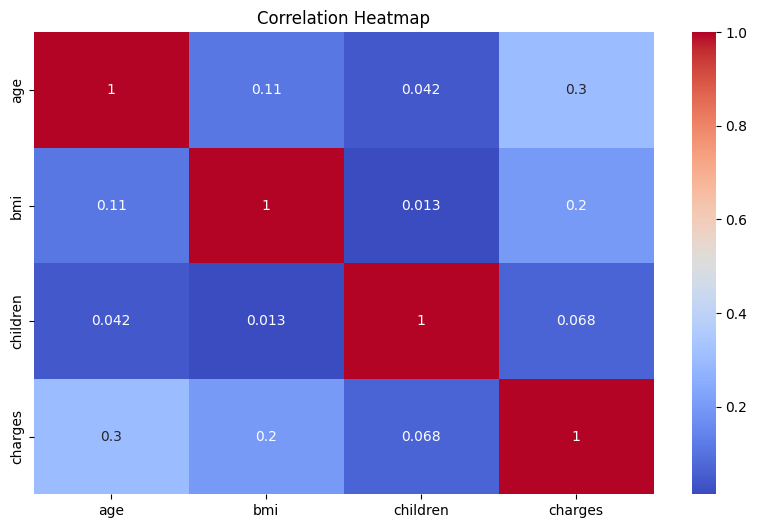

In [6]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# **8. Encode Categorical Variables**

**Label Encoding**

In [7]:
encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])

df['smoker'] = encoder.fit_transform(df['smoker'])

df['region'] = encoder.fit_transform(df['region'])

# **9. Feature Selection**

**Input Features**

In [8]:
X = df.drop('charges', axis=1)

**Target Variable**

In [9]:
y = df['charges']

# **10. Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **11. Train Machine Learning Models**

**A. Linear Regression**

In [11]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

**B. Random Forest Regressor**

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

**C. XGBoost Regressor**

In [13]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

# **12. Model Evaluation**

**Evaluation Function**

In [14]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-"*30)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

# **Evaluate All Models**

In [15]:
evaluate_model(y_test, lr_preds, "Linear Regression")

evaluate_model(y_test, rf_preds, "Random Forest")

evaluate_model(y_test, xgb_preds, "XGBoost")


Linear Regression
------------------------------
MAE  : 4186.51
RMSE : 5799.59
R2   : 0.7833

Random Forest
------------------------------
MAE  : 2501.34
RMSE : 4570.98
R2   : 0.8654

XGBoost
------------------------------
MAE  : 2462.38
RMSE : 4490.36
R2   : 0.8701


# **13. Visualization**

**Actual vs Predicted Charges**

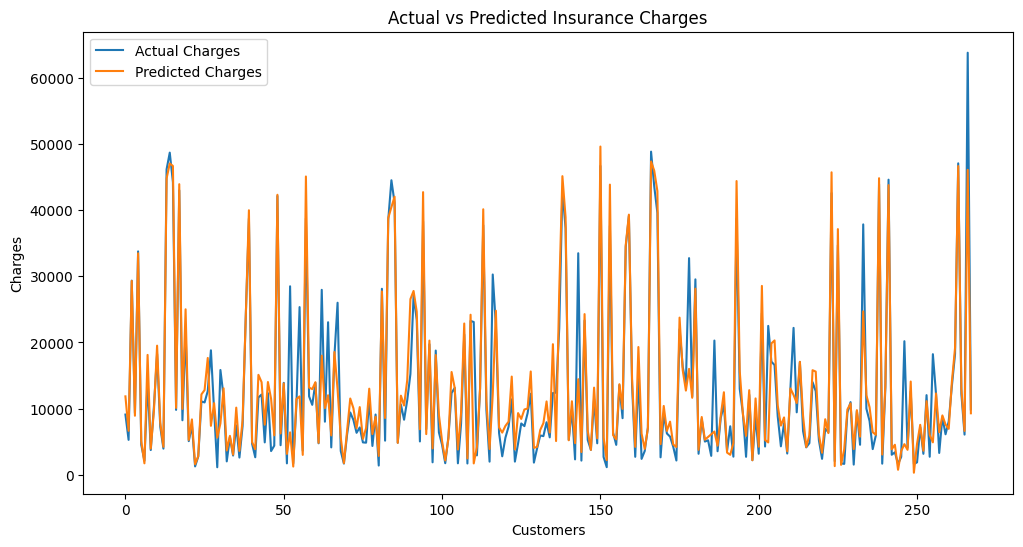

In [16]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,
         label='Actual Charges')

plt.plot(xgb_preds,
         label='Predicted Charges')

plt.title("Actual vs Predicted Insurance Charges")

plt.xlabel("Customers")

plt.ylabel("Charges")

plt.legend()

plt.show()

# **14. Feature Importance**

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
4    smoker    0.934668
2       bmi    0.026835
0       age    0.020135
3  children    0.007504
5    region    0.006804
1       sex    0.004053


# **15. Predict Charges for New Customer**

In [18]:
new_customer = [[
    35,     # age
    1,      # sex (male)
    28.5,   # bmi
    2,      # children
    1,      # smoker
    2       # region
]]

predicted_charge = xgb_model.predict(new_customer)

print("Predicted Insurance Charge:",
      predicted_charge[0])

Predicted Insurance Charge: 21555.195


# **16. Important Concepts Learned**

**This project teaches:**

Regression analysis

Healthcare cost prediction

Feature encoding

Ensemble learning

Model evaluation

Predictive analytics

Data visualization

Real-world insurance analytics

# **17. Mathematical Understanding**

**Linear Regression Formula**

y=β
0	​
+β
1	​
x
1	​
+β
2	​
x
2	​
+⋯+β
n
x
n


  ​
**Where:**

y = predicted insurance charge

x = input features

β = model coefficients

# **RMSE Formula**

**RMSE**=
n
1
	​

∑
i=1
n	​
(y
i	​
−
y
^	​
i	​
)
2
	​


Lower RMSE means better predictions.

# **18. Advanced Improvements**

**You can improve this project using:**

**Advanced Models**

CatBoost

LightGBM

Neural Networks

**Better Features**

Medical history

Exercise habits

Income level

Chronic disease indicators

**Deployment**

Streamlit insurance calculator

Flask REST API

Docker deployment

Cloud deployment

# **19. Interview Questions**

**Why is smoker status important?**

Smoking significantly increases medical risk and healthcare costs.

**Why use ensemble models?**

Ensemble models combine multiple decision trees to improve prediction accuracy.

**Difference between MAE and RMSE?**

MAE measures average absolute error
RMSE penalizes large prediction errors more strongly

# **Resume Description**

Developed a machine learning insurance cost prediction system using regression and ensemble learning algorithms to estimate customer medical charges with high prediction accuracy using demographic and health-related features.

# **Results & Learning Outcomes**

Through this project, I successfully built a machine learning model to predict insurance charges based on customer demographic and health-related information. I learned how to preprocess structured datasets, encode categorical variables, train regression models, and evaluate prediction performance using multiple evaluation metrics.

**This project improved my understanding of:**

Regression algorithms for cost prediction

Data preprocessing and categorical encoding

Exploratory Data Analysis (EDA)

Feature importance analysis

Ensemble learning techniques

Model evaluation using MAE, RMSE, and R² score

Comparing multiple machine learning models

Among all models, XGBoost achieved the highest prediction accuracy and lowest error rate, making it the best-performing model for insurance charge prediction.

**The project also enhanced my practical skills in:**

Python programming

Pandas and NumPy

Data visualization with Matplotlib and Seaborn

Scikit-learn machine learning workflow

Predictive analytics for insurance applications

Overall, this project provided hands-on experience in developing a real-world insurance analytics system capable of estimating medical costs for new customers accurately.